## Set up data and model objects

In [1]:
import pandas as pd
import numpy as np

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from torch.distributions import NegativeBinomial
from pyro.distributions import LogNormalNegativeBinomial


import mudata as md
import perturbo
import seaborn as sns
import pyro
from scipy.stats import norm
import matplotlib.pyplot as plt
import torch

# smoke_test=True # only use selected genes
smoke_test=False # run full analysis


torch.cuda.device_count()

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


0

In [2]:
import scvi
scvi.settings.seed = 0 

Global seed set to 0


Set training configuration and access to data

### Load the data
(50k cells, takes ~30 seconds)

In [3]:
data_dir = "../../../../Data/gasperini_pilot"
batch_size=4096 # multiple of 64

mdata = md.read_h5mu(f'{data_dir}/gasperini_pilot_highMOI.h5mu')
# batch_size=None
mdata

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


MuData object with n_obs × n_vars = 47964 × 19482
  2 modalities
    rna:	47964 x 16367
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 3115
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [4]:
# data_dir = "/data/pinello/SHARED_DATA/gasperini_2019"
# data_dir = "/work/data/SHARED_DATA/gasperini_2019"

selected_guides = mdata["grna"].var_names[:10]
# selected_guides = ["ACTB_TSS|1", "ACTB_TSS|2", "ACTG1_TSS|1", "ACTG1_TSS|2"]
selected_genes = sorted({sg.split("_")[0] for sg in selected_guides})
if torch.cuda.is_available():
    accelerator = "gpu"
    print("training using GPU")
else:
    accelerator = "cpu"
    print("training using CPU")


training using CPU


In [5]:
if smoke_test:
    n_steps = 1
else:
    n_steps = scvi.model._utils.get_max_epochs_heuristic(len(mdata), epochs_cap=1000, decay_at_n_obs=5000)
n_steps

104

In [6]:
sceptre_df = pd.read_csv(f"{data_dir}/sceptre_results-2023_01_13.csv")
sceptre_df = sceptre_df.rename(columns={"gRNA_id": "guide", "gene_id": "gene", "z_value":"SCEPTRE_z_value","p_value":"SCEPTRE_p_value"})
sceptre_df


,gene,guide,pair_type,SCEPTRE_p_value,SCEPTRE_z_value,log_fold_change
0,Y_RNA,ACTB_TSS|1,positive_control,0.940707,1.632176,0.469126
1,FOXK1,ACTB_TSS|1,positive_control,0.153629,-0.992648,-0.088097
2,AP5Z1,ACTB_TSS|1,positive_control,0.123562,-1.010549,-0.119240
3,RADIL,ACTB_TSS|1,positive_control,0.057483,-1.501497,-0.386814
4,RNF216P1,ACTB_TSS|1,positive_control,0.341734,-0.635756,-0.034944
...,...,...,...,...,...,...
22261,SNORD60,scrambled_9|2,negative_control,0.950426,1.765242,0.708387
22262,DCAKD,scrambled_9|2,negative_control,0.488787,-0.149950,-0.027133
22263,RNF213-AS1,scrambled_9|2,negative_control,0.847978,1.018406,0.507472
22264,NAPB,scrambled_9|2,negative_control,0.696904,0.508168,0.149431


In [7]:
if not smoke_test or selected_genes is None:
    selected_genes = sceptre_df["gene"].unique()
if not smoke_test or selected_guides is None:
    selected_guides = sceptre_df["guide"].unique()

print(len(selected_genes), len(selected_guides))
# sceptre_df.query("guide=='GATA2_TSS|1'")


5859 1243


In [8]:
sceptre_df.query("pair_type=='negative_control'")

,gene,guide,pair_type,SCEPTRE_p_value,SCEPTRE_z_value,log_fold_change
21272,Metazoa_SRP,random_1|1,negative_control,0.225595,-0.745345,-0.331922
21273,OR2G6,random_1|1,negative_control,0.985559,2.585539,0.942606
21274,SLC3A2,random_1|1,negative_control,0.874096,1.930871,0.153495
21275,PTPN11,random_1|1,negative_control,0.685826,0.454581,0.040252
21276,CORO7,random_1|1,negative_control,0.847094,1.114626,0.175454
...,...,...,...,...,...,...
22261,SNORD60,scrambled_9|2,negative_control,0.950426,1.765242,0.708387
22262,DCAKD,scrambled_9|2,negative_control,0.488787,-0.149950,-0.027133
22263,RNF213-AS1,scrambled_9|2,negative_control,0.847978,1.018406,0.507472
22264,NAPB,scrambled_9|2,negative_control,0.696904,0.508168,0.149431


In [9]:
grna_subset = mdata.mod['grna'][:,selected_guides]
# grna_subset.X *= 0 # NO GUIDE INFLUENCE
rna_subset = mdata.mod['rna'][:,selected_genes]
mdata = md.MuData({'rna':rna_subset, 'grna':grna_subset}).copy()
mdata

MuData object with n_obs × n_vars = 47964 × 7102
  2 modalities
    rna:	47964 x 5859
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47964 x 1243
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

In [10]:
mdata['grna'].varm['element_targeted']


,ACTB_TSS,ACTG1_TSS,ACYP1_TSS,ADIPOR1_TSS,ALDH1A2_TSS,APEX1_TSS,APLP2_TSS,ARF6_TSS,ARID1A_TSS,ARL4A_TSS,...,scrambled_24,scrambled_25,scrambled_2,scrambled_3,scrambled_4,scrambled_5,scrambled_6,scrambled_7,scrambled_8,scrambled_9
ACTB_TSS|1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTB_TSS|2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACTG1_TSS|2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ACYP1_TSS|1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
scrambled_7|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
scrambled_8|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
scrambled_8|2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
scrambled_9|1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Register data with perturbo

In [11]:
# element_names1 = model.adata_manager.get_state_registry("tested_elements")['column_names']
# element_names2 = model.adata_manager.get_state_registry("targeted_elements")['column_names']
# assert element_names1 == element_names2

In [12]:
# %pip install scikit-misc

In [13]:
# sc.pp.highly_variable_genes(mdata['rna'], flavor='seurat_v3', batch_key="bath_number", n_top_genes=1000)
# # sc.pp.neighbors(mdata['rna'])
# sc.tl.pca(mdata['rna'])


In [14]:
mdata['rna'].obs

,bath_number,percent_mito,log_number_of_detected_genes,log_total_gene_count,log_total_guide_count,library_size
TTGAACGCAAGCGAGT,6,0.029057,8.385489,8.385717,7.330405,20602.0
ATTACTCGTGGTAACG,1,0.025976,8.254529,8.254789,5.986452,14048.0
GTAGTCATCGTTGACA,5,0.042747,8.206584,8.206856,5.225747,13701.0
GTGTGCGTCCCGACTT,4,0.042587,8.327726,8.327968,5.700444,17474.0
GCATGCGAGAAACGAG,3,0.021318,7.806289,7.806696,7.071573,8807.0
...,...,...,...,...,...,...
GGAATAATCTGGGCCA,3,0.091893,8.316056,8.316300,5.793014,15244.0
GTCCTCATCTTGTATC,6,0.043563,7.293698,7.294377,6.093570,3588.0
CCACTACGTAGAGCTG,6,0.021208,8.134761,8.135054,6.400258,12897.0
CGTTCTGAGGATGGTC,6,0.025178,8.203851,8.204125,5.730100,13752.0


In [15]:
mdata[mdata['rna'].obs['percent_mito']<0.1,:]

View of MuData object with n_obs × n_vars = 47679 × 7102
  2 modalities
    rna:	47679 x 5859
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count', 'library_size'
      varm:	'element_tested'
    grna:	47679 x 1243
      obs:	'bath_number', 'percent_mito', 'log_number_of_detected_genes', 'log_total_gene_count', 'log_total_guide_count'
      varm:	'element_targeted'

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/scanpy/plotting/_utils.py:715: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


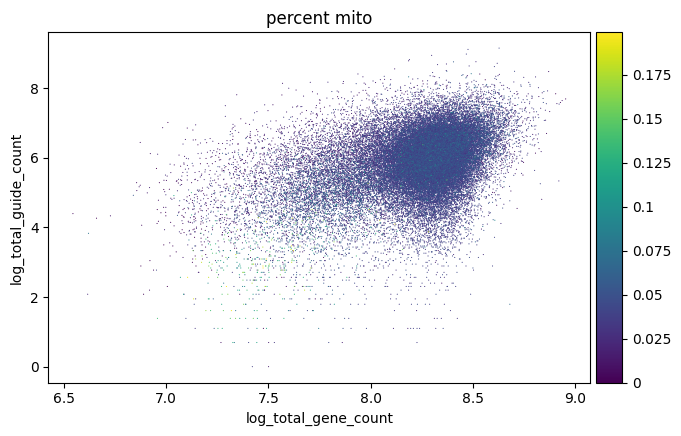

In [16]:
# mdata.update()
import scanpy as sc

# mdata = mdata[mdata['rna'].obs['percent_mito']<0.1,:].copy()
# mdata = mdata[mdata['rna'].obs['log_total_gene_count'].between(8.1,8.5),:].copy()
sc.pl.scatter(mdata['rna'],"log_total_gene_count", "log_total_guide_count", "percent_mito")
# mdata

In [17]:
# sc.pl.pca(mdata['rna'], color="bath_number")
# sc.pl.pca(mdata['rna'], color="percent_mito")
mdata['rna'].X.mean(axis=0).shape

(1, 5859)

In [18]:
perturbo.PERTURBO.setup_mudata(
    mdata,
    batch_key="bath_number",
    library_size_key="library_size",
    continuous_covariates_keys=["log_total_guide_count", "percent_mito"],
    guide_by_element_key="element_targeted",
    gene_by_element_key="element_tested",
    modalities={
        "rna_layer": "rna",
        "perturbation_layer": "grna",
    },
)

model = perturbo.PERTURBO(mdata, likelihood="nb", n_factors=None)
model.view_anndata_setup()


INFO     Using column names from columns of adata.varm['element_tested']                                           
INFO     Using column names from columns of adata.varm['element_targeted']                                         


/Users/ljb80/mambaforge/lib/python3.10/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
/Users/ljb80/mambaforge/lib/python3.10/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


Anndata setup with scvi-tools version 1.0.4.

Setup via `PERTURBO.setup_anndata` with arguments:

{
│   'rna_layer': None,
│   'perturbation_layer': None,
│   'batch_key': None,
│   'gene_by_element_key': 'element_tested',
│   'rna_element_uns_key': None,
│   'guide_element_uns_key': None,
│   'guide_by_element_key': 'element_targeted',
│   'library_size_key': 'library_size',
│   'size_factor_key': None,
│   'continuous_covariates_keys': None,
│   'categorical_covariates_keys': None,
│   'modalities': {'rna_layer': 'rna', 'perturbation_layer': 'grna'}
}

       Summary Statistics       
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃   Summary Stat Key   ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│       n_batch        │   1   │
│       n_cells        │ 47964 │
│ n_gene_summary_stats │   1   │
│   n_perturbations    │ 1243  │
│ n_targeted_elements  │ 1561  │
│  n_tested_elements   │ 1561  │
│        n_vars        │ 5859  │
└──────────────────────┴───────┘

                              Data Registry                               
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃    Registry Key    ┃                scvi-tools Location                ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         X          │                adata.mod['rna'].X                 │
│       batch        │        adata.mod['rna'].obs['_scvi_batch']        │
│ gene_summary_stats │ adata.mod['rna'].varm['_scvi_gene_summary_stats'] │
│       ind_x        │          adata.mod['rna'].obs['_ind_x']           │
│   perturbations    │                adata.mod['grna'].X                │
│    size_factor     │       adata.mod['rna'].obs['_size_factor']        │
│ targeted_elements  │    adata.mod['grna'].varm['element_targeted']     │
│  tested_elements   │      adata.mod['rna'].varm['element_tested']      │
└────────────────────┴───────────────────────────────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

 gene_summary_stats State  
         Registry          
┏━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location     ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.var['_gene_mean'] │
└─────────────────────────┘

### Train the model

In [19]:
list(pyro.get_param_store().keys())


[]

In [20]:
# burn-in
pyro.clear_param_store()

# len(mdata['rna'])/batch_size
# # 0.9**(1/11)# from pyro.optim import ClippedAdam
from torch.optim import Adam
from pyro.infer import TraceMeanField_ELBO
from math import ceil

optimizer = Adam
steps_per_epoch = ceil(model.module.n_cells / batch_size)
# scheduler = pyro.optim.MultiStepLR(
#     {
#         "optimizer": optimizer,
#         "optim_args": {"lr": 0.1},
#         "gamma": 0.3,
#         # "milestones": [steps_per_epoch * 10, steps_per_epoch*20],
#         "milestones": [10, 20],
#     }
# )

# scheduler = pyro.optim.ReduceLROnPlateau(
#     {
#         "optimizer": optimizer,
#         "optim_args": {"lr": 0.1},
#         "threshold": 1e-2,
#         "patience": 5,
#         "factor": 0.3,
#     }
# )


def plot_gene_distribution(medians, gene_name="ACTB", x_max=100, log_y_scale=False):
    gene_idx = np.where(mdata["rna"].var_names == gene_name)[0][0]
    tss_guides = mdata["grna"].var_names[mdata["grna"].var_names.str.startswith(gene_name + "_TSS")]
    has_tss_guide = mdata["grna"][:, tss_guides].X.sum(axis=1) > 0
    data_df = mdata["rna"][:, gene_idx].to_df()
    data_df["has_TSS_guide"] = has_tss_guide
    print(has_tss_guide.shape)
    print(tss_guides)
    log_gene_means = medians["log_gene_mean"]
    log_gene_dispersions = medians["log_gene_dispersion"]
    x = torch.tensor(np.arange(x_max))
    logit = log_gene_means[gene_idx]
    total_count = log_gene_dispersions[gene_idx].exp()
    if model.module.likelihood == "nb":
        ndist = NegativeBinomial(logits=logit - total_count.log(), total_count=total_count)
    elif model.module.likelihood == "lnnb":
        multiplicative_noise = medians["multiplicative_noise"][gene_idx]
        ndist = LogNormalNegativeBinomial(
            logits=logit - total_count.log() - multiplicative_noise**2 / 2,
            total_count=total_count,
            multiplicative_noise_scale=multiplicative_noise,
            num_quad_points=32,
        )
    probs = ndist.log_prob(x).exp()
    plt.plot(x, probs)
    sns.histplot(data_df, x=gene_name, bins=x, stat="density", hue="has_TSS_guide")
    plt.title(f'gene: {mdata["rna"].var_names[gene_idx]}')
    print(f'logit={logit:.2f}, total_count={total_count:.2f}')
    if model.module.likelihood == "lnnb":
        print(f'multiplicative_noise={multiplicative_noise:.2f}')
    if log_y_scale:
        plt.semilogy()
    plt.show()
    return data_df

In [21]:
# model.train(
#     1,
#     lr=0.000001,
#     batch_size=128,
#     accelerator=accelerator,
# )
# plot_gene_distribution(model.module.guide.median())

In [22]:
model

MyPyroModel Model with params:
n_batch: 1
n_cells: 47964
n_gene_summary_stats: 1
n_perturbations: 1243
n_targeted_elements: 1561
n_tested_elements: 1561
n_vars: 5859

Training status: Not Trained
Model's adata is minified?: False

In [23]:
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.callbacks import Callback

medians = []


class LogGeneMeanCallback(Callback):
    def __init__(self):
        self.epoch = 0

    # def on_train_epoch_end(self, trainer, pl_module):
    #     print(f"Epoch:{self.epoch}")
    #     self.epoch += 1
    #     log_gene_mean = pl_module.module.guide.median()["log_gene_mean"]
    # pl_module.logger.history["log_gene_mean"] = log_gene_mean[0]
    # trainer.logger.log_metrics({"log_gene_mean", log_gene_mean[0]})
    # trainer.logger.log_metrics({"epoch":self.epoch, "log_gene_mean":log_gene_mean[0]}, self.epoch)
    # trainer.logger.experiment.log_metrics({"epoch":self.epoch, "log_gene_mean":log_gene_mean[0]})
    # trainer.logger.log_


# n_epochs=100
# for _ in range(n_epochs):

checkpoint_callback = ModelCheckpoint(
    dirpath="checkpoints/", every_n_epochs=10, save_top_k=-1, save_on_train_epoch_end=True
)

model.train(
    100,
    lr=0.01,
    batch_size=512,
    callbacks=[checkpoint_callback, LogGeneMeanCallback()],
    enable_checkpointing=True,
)

# medians.append(model.module.guide.median())

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/lightning/pytorch/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:617: UserWarning: Checkpoint directory checkpoints/ exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
/Users/l

Epoch 9/100:   8%|▊         | 8/100 [15:08<2:52:42, 112.63s/it, v_num=1, elbo_train=2.19e+8]

In [ ]:
checkpoint = torch.load("checkpoints/epoch=9-step=660.ckpt")
# checkpoint = torch.load("checkpoints/epoch=89-step=5940.ckpt")

# state_model.module.load_state_dict(checkpoint["state_dict"])
offset = len("module.")
new_dict = {k[len("module."):]: v for k, v in checkpoint["state_dict"].items() if k != "_dummy_param"}

model.module.load_state_dict(new_dict)
model.module.guide.median()
# for k, v in checkpoint["state_dict"].items():
    # print(k)

{'guide_efficacy': tensor([[0.8908],
         [0.8881],
         [0.8881],
         [0.8855],
         [0.8859],
         [0.8902],
         [0.8893],
         [0.8826],
         [0.8854],
         [0.8820]]),
 'log_gene_mean': tensor([2.8267, 2.3919, 0.2769, 1.1262, 0.6522]),
 'log_gene_dispersion': tensor([5.4639, 3.9828, 2.0212, 2.5573, 4.1894]),
 'multiplicative_noise': tensor([0.3418, 0.5701, 0.0648, 0.0277, 0.6575]),
 'batch_effect': tensor([[ 0.2198, -0.2672,  0.0393, -0.0987,  0.3397]]),
 'cont_covariate_effect': tensor([[-0.0379, -0.0922, -0.0004, -0.0404, -0.0646]]),
 'element_effects': tensor([ 0.0215,  0.0045,  0.0070,  0.0060, -0.0026, -0.0207,  0.0179, -0.0188,
          0.0647,  0.1187, -0.0112, -0.0094, -0.0010, -0.0372, -0.0199,  0.0030,
          0.0419, -0.0200, -0.0333, -0.0434])}

In [ ]:
model

{'elbo_train':          elbo_train
 epoch              
 0      500274.03125
 1      479724.03125
 2          454833.5
 3      438864.46875
 4        430230.375
 ...             ...
 1007   406178.53125
 1008     406107.375
 1009   406160.46875
 1010   406458.15625
 1011      406311.25
 
 [1012 rows x 1 columns]}

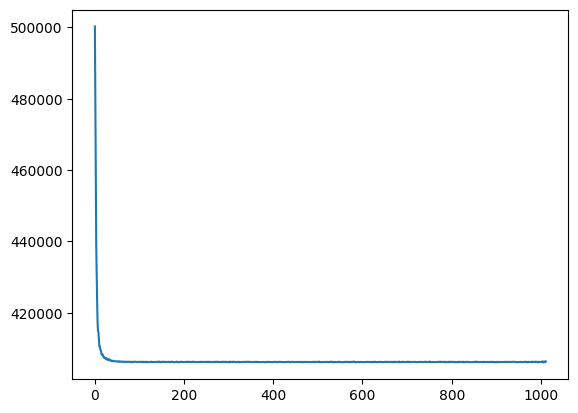

In [ ]:
plt.plot(model.history["elbo_train"])

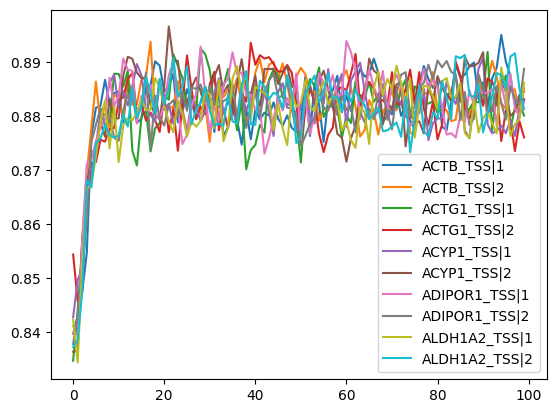

In [ ]:
efficacy = torch.stack([m["guide_efficacy"].squeeze() for m in medians])
for i, guide in enumerate(mdata["grna"].var_names):
    plt.plot(range(n_epochs), efficacy[:,i], label=guide)
plt.legend()

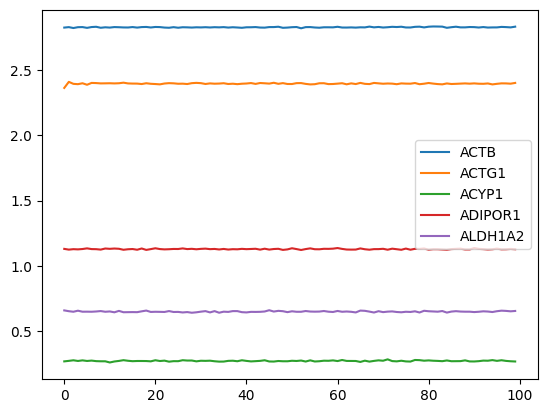

In [ ]:
mean = torch.stack([m["log_gene_mean"].squeeze() for m in medians])
for i, guide in enumerate(mdata["rna"].var_names):
    plt.plot(range(n_epochs), mean[:,i], label=guide)
plt.legend()

Text(0.5, 1.0, 'log gene dispersion')

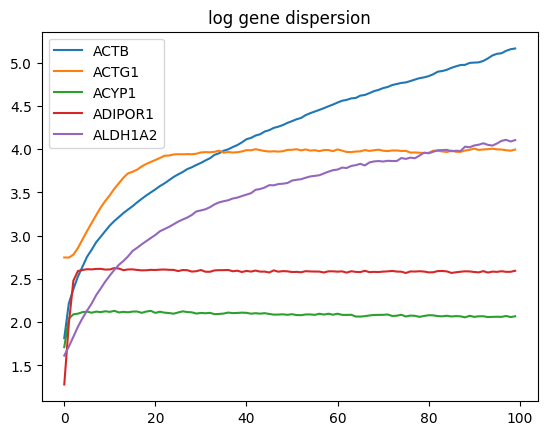

In [ ]:
disp = torch.stack([m["log_gene_dispersion"].squeeze() for m in medians])
for i, guide in enumerate(mdata["rna"].var_names):
    plt.plot(range(n_epochs), disp[:,i], label=guide)
plt.legend()
plt.title("log gene dispersion")

Text(0.5, 1.0, 'extra multiplicative noise')

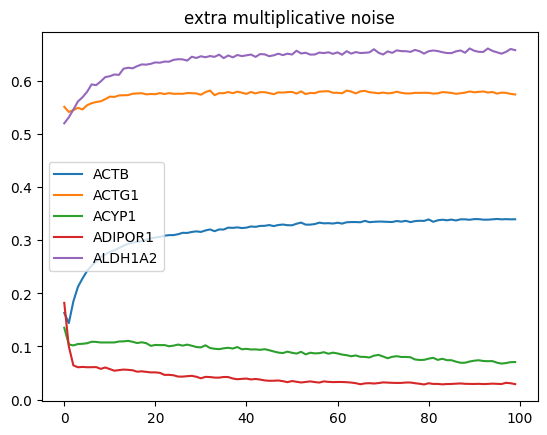

In [ ]:
extra_noise = torch.stack([m["multiplicative_noise"].squeeze() for m in medians])
for i, guide in enumerate(mdata["rna"].var_names):
    plt.plot(range(n_epochs), extra_noise[:,i], label=guide)
plt.legend()
plt.title("extra multiplicative noise")

(33368,)
Index(['ACTB_TSS|1', 'ACTB_TSS|2'], dtype='object')
logit=2.83, total_count=174.77
multiplicative_noise=0.34


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be r

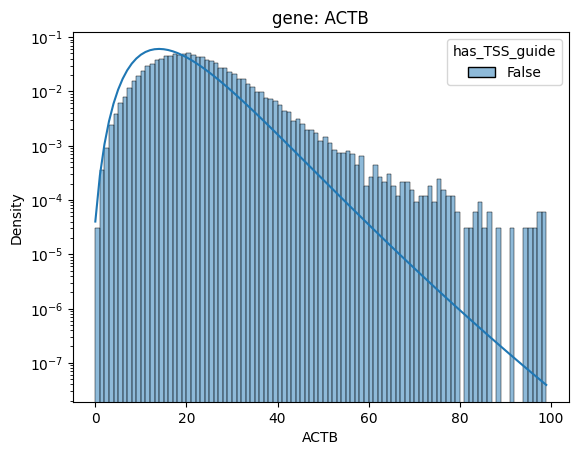

(33368,)
Index(['ACTG1_TSS|1', 'ACTG1_TSS|2'], dtype='object')
logit=2.40, total_count=54.37
multiplicative_noise=0.57


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be r

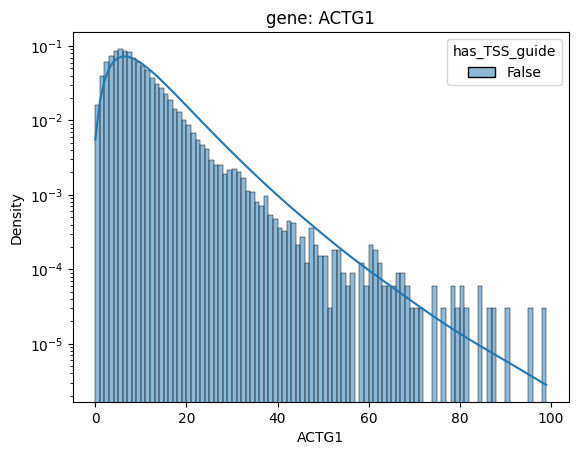

(33368,)
Index(['ACYP1_TSS|1', 'ACYP1_TSS|2'], dtype='object')
logit=0.27, total_count=7.91
multiplicative_noise=0.07


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be r

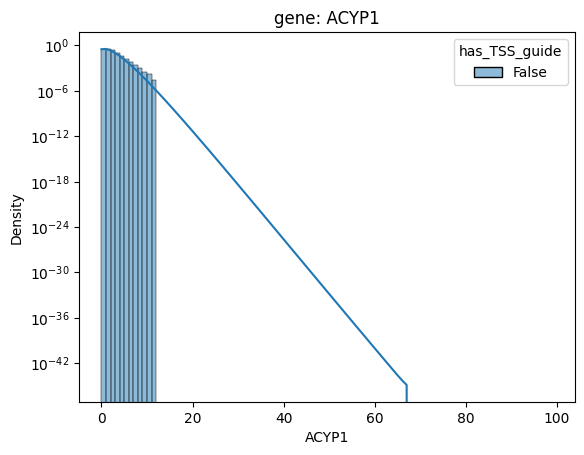

(33368,)
Index(['ADIPOR1_TSS|1', 'ADIPOR1_TSS|2'], dtype='object')
logit=1.13, total_count=13.39
multiplicative_noise=0.03


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be r

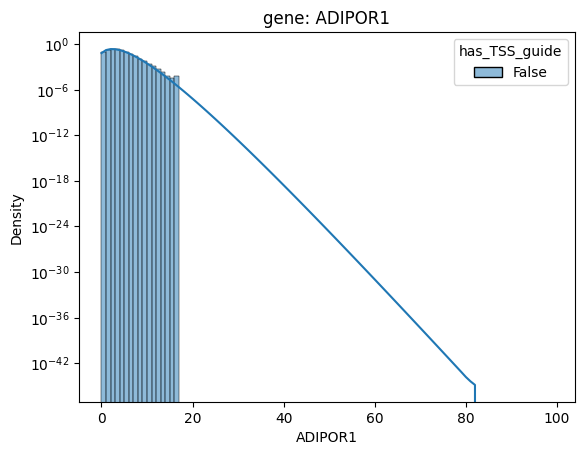

(33368,)
Index(['ALDH1A2_TSS|1', 'ALDH1A2_TSS|2'], dtype='object')
logit=0.65, total_count=60.61
multiplicative_noise=0.66


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be r

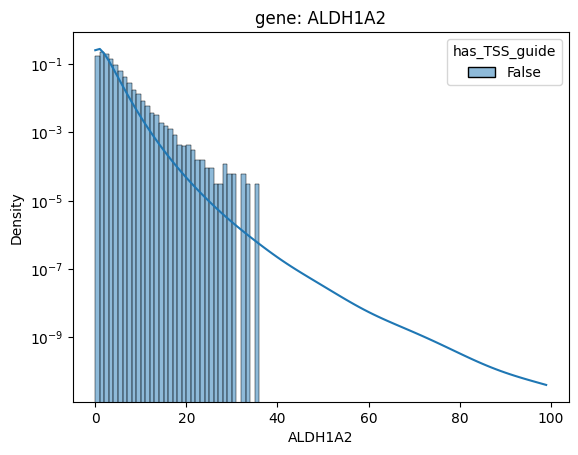

In [ ]:
for sg in selected_genes:
    plot_gene_distribution(model.module.guide.median(), gene_name=sg, log_y_scale=True)

(33368,)
Index(['ACTB_TSS|1', 'ACTB_TSS|2'], dtype='object')
logit=2.83, total_count=174.77
multiplicative_noise=0.34


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be r

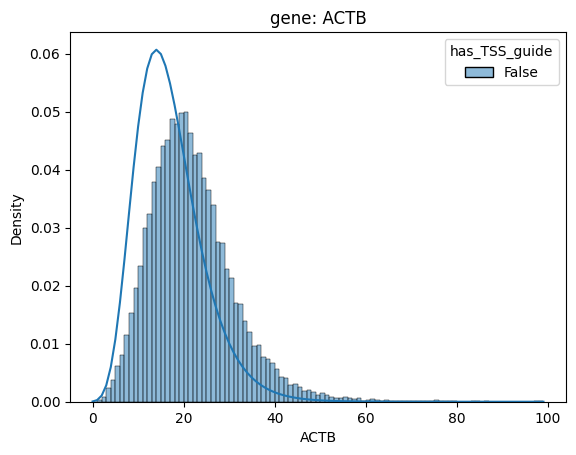

(33368,)
Index(['ACTG1_TSS|1', 'ACTG1_TSS|2'], dtype='object')


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be r

logit=2.40, total_count=54.37
multiplicative_noise=0.57


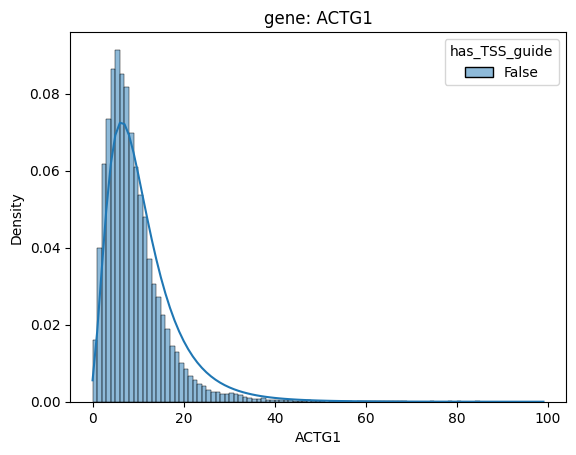

(33368,)
Index(['ACYP1_TSS|1', 'ACYP1_TSS|2'], dtype='object')


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be r

logit=0.27, total_count=7.91
multiplicative_noise=0.07


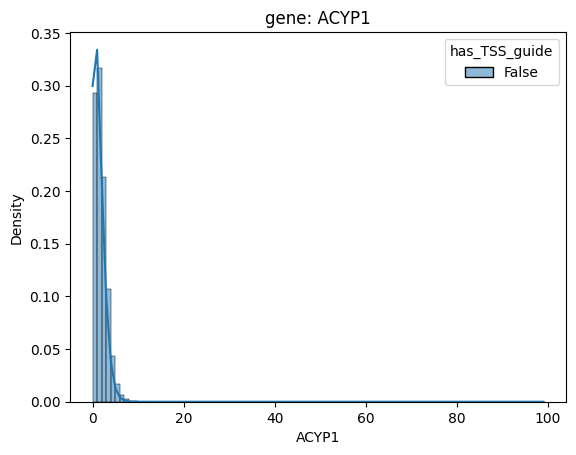

(33368,)
Index(['ADIPOR1_TSS|1', 'ADIPOR1_TSS|2'], dtype='object')


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be r

logit=1.13, total_count=13.39
multiplicative_noise=0.03


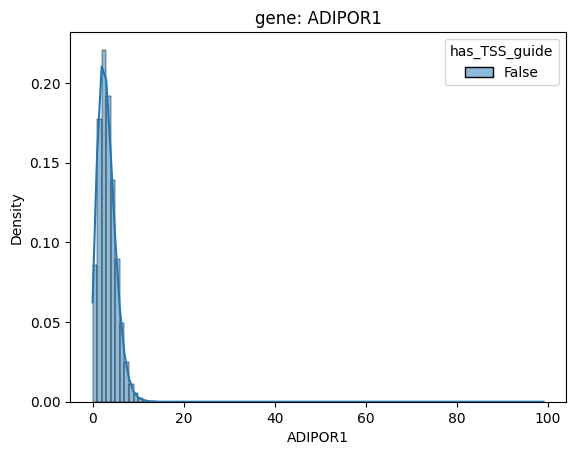

(33368,)
Index(['ALDH1A2_TSS|1', 'ALDH1A2_TSS|2'], dtype='object')


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be r

logit=0.65, total_count=60.61
multiplicative_noise=0.66


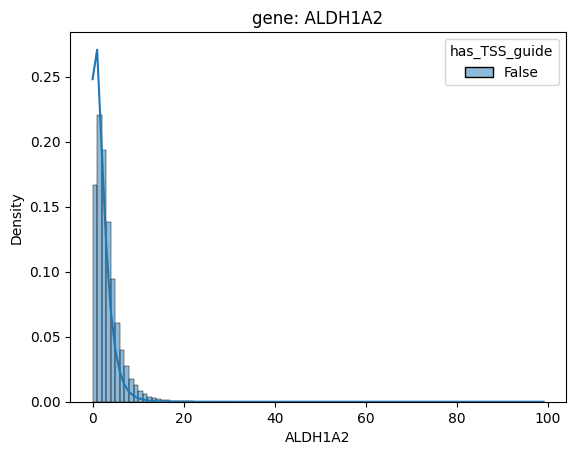

In [ ]:
for sg in selected_genes:
    plot_gene_distribution(model.module.guide.median(), gene_name=sg, log_y_scale=False)

In [ ]:

# for _ in range(10):
#     model.train(
#         10,
#         lr=0.01,
#         batch_size=1024,
#         accelerator=accelerator,
#     )
#     plot_gene_distribution(model.module.guide.median())


# # plan_kwargs = {'optim': pyro.optim.ClippedAdam(dict(lr=0.1, lrd=0.96))}
# # model.train(20, lr=0.05, batch_size=512, use_gpu=use_gpu)
# # model.train(20, lr=0.05, batch_size=512, use_gpu=use_gpu)


In [ ]:
# medians = model.module.guide.median()
# log_gene_means = medians["log_gene_mean"]
# log_gene_dispersions = medians["log_gene_dispersion"]
# @interact(gene_idx = (0, mdata["rna"].n_vars), x_max=(0,100))
# def plot_gene_distribution(gene_idx=0, x_max=20, log_y_scale=False):
#     x = torch.tensor(np.arange(x_max))
#     logit = log_gene_means[gene_idx]
#     total_count = log_gene_dispersions[gene_idx].exp()
#     ndist = NegativeBinomial(logits = logit-log_gene_dispersions[gene_idx], total_count=total_count)
#     probs = ndist.log_prob(x).exp()
#     plt.plot(x, probs)
#     plt.hist(mdata["rna"].X[:,gene_idx].todense(), bins=x, density=True)
#     plt.title(f'gene: {mdata["rna"].var_names[gene_idx]}, logit={logit:.2f}, total_count={total_count:.2f}')
#     if log_y_scale:
#         plt.semilogy()

In [ ]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)
    if sum(v.shape) <= 1:
        print(v)

AutoGuideList.0.locs.guide_efficacy torch.Size([10, 1])
AutoGuideList.0.scales.guide_efficacy torch.Size([10, 1])
AutoGuideList.0.locs.log_gene_mean torch.Size([5])
AutoGuideList.0.scales.log_gene_mean torch.Size([5])
AutoGuideList.0.locs.log_gene_dispersion torch.Size([5])
AutoGuideList.0.scales.log_gene_dispersion torch.Size([5])
AutoGuideList.0.locs.multiplicative_noise torch.Size([5])
AutoGuideList.0.scales.multiplicative_noise torch.Size([5])
AutoGuideList.0.locs.batch_effect torch.Size([1, 5])
AutoGuideList.0.scales.batch_effect torch.Size([1, 5])
AutoGuideList.0.locs.cont_covariate_effect torch.Size([1, 5])
AutoGuideList.0.scales.cont_covariate_effect torch.Size([1, 5])
perturbo$$$_guide.0.locs.guide_efficacy_unconstrained torch.Size([10, 1])
perturbo$$$_guide.0.locs.log_gene_mean_unconstrained torch.Size([5])
perturbo$$$_guide.0.locs.log_gene_dispersion_unconstrained torch.Size([5])
perturbo$$$_guide.0.locs.multiplicative_noise_unconstrained torch.Size([5])
perturbo$$$_guide.0.

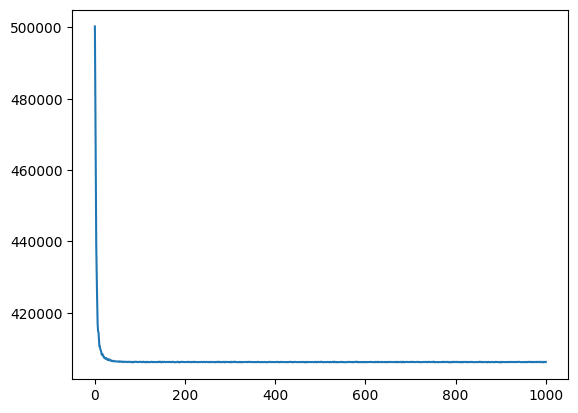

In [ ]:
plt.plot(model.history["elbo_train"])


In [ ]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)
    if sum(v.shape) <= 1:
        print(v)

AutoGuideList.0.locs.guide_efficacy torch.Size([10, 1])
AutoGuideList.0.scales.guide_efficacy torch.Size([10, 1])
AutoGuideList.0.locs.log_gene_mean torch.Size([5])
AutoGuideList.0.scales.log_gene_mean torch.Size([5])
AutoGuideList.0.locs.log_gene_dispersion torch.Size([5])
AutoGuideList.0.scales.log_gene_dispersion torch.Size([5])
AutoGuideList.0.locs.multiplicative_noise torch.Size([5])
AutoGuideList.0.scales.multiplicative_noise torch.Size([5])
AutoGuideList.0.locs.batch_effect torch.Size([1, 5])
AutoGuideList.0.scales.batch_effect torch.Size([1, 5])
AutoGuideList.0.locs.cont_covariate_effect torch.Size([1, 5])
AutoGuideList.0.scales.cont_covariate_effect torch.Size([1, 5])
perturbo$$$_guide.0.locs.guide_efficacy_unconstrained torch.Size([10, 1])
perturbo$$$_guide.0.locs.log_gene_mean_unconstrained torch.Size([5])
perturbo$$$_guide.0.locs.log_gene_dispersion_unconstrained torch.Size([5])
perturbo$$$_guide.0.locs.multiplicative_noise_unconstrained torch.Size([5])
perturbo$$$_guide.0.

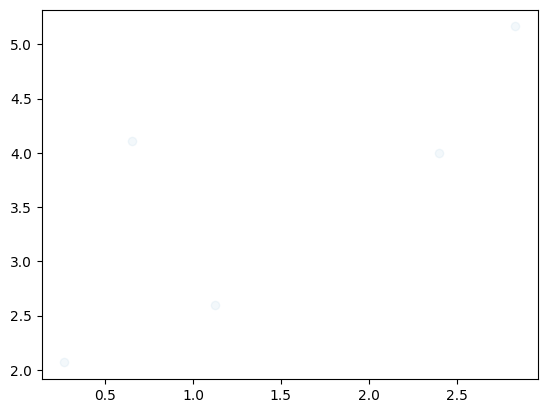

In [ ]:
mean = model.module.guide.median()['log_gene_mean'].numpy()
dispersion = model.module.guide.median()['log_gene_dispersion'].numpy()
plt.scatter(mean, dispersion, alpha=0.05)


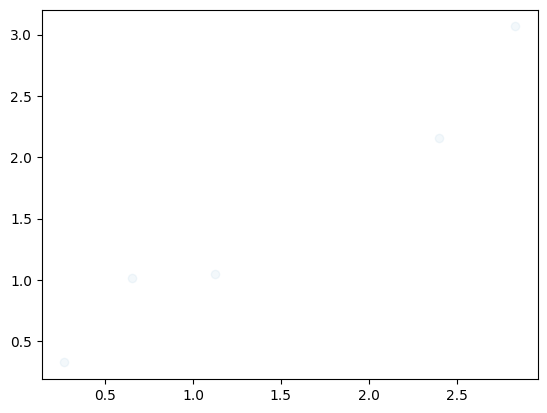

In [ ]:
plt.scatter(mean, np.log(mdata['rna'].X.mean(axis=0).A1), alpha=0.05)


In [ ]:

from scipy.sparse import coo_matrix, issparse

element_effects = model.get_element_effects()
element_effects = element_effects.assign(
    is_target=lambda x: x["element"].str.split("_", expand=True)[0] == x["gene"],
)
element_effects

,loc,scale,element,gene,z_value,q_value,is_target
8,-0.035021,0.160667,chr14:75696446-75696469,ACYP1,-0.217971,0.827452,False
6,-0.032504,0.158666,UBE2T_TSS,ADIPOR1,-0.204856,0.837685,False
17,-0.032845,0.167831,chr1:202938058-202938081,ADIPOR1,-0.195702,0.844844,False
5,-0.027240,0.168226,TMED10_TSS,ACYP1,-0.161926,0.871364,False
13,-0.020886,0.164305,chr1:202074787-202074810,ADIPOR1,-0.127115,0.898849,False
9,-0.020768,0.163984,chr15:58242503-58242526,ALDH1A2,-0.126645,0.899222,False
16,-0.020217,0.161398,chr1:202134520-202134543,ADIPOR1,-0.125259,0.900319,False
18,-0.017022,0.161680,chr1:202974831-202974854,ADIPOR1,-0.105281,0.916153,False
1,-0.017069,0.164965,ACTG1_TSS,ACTG1,-0.103473,0.917588,True
0,-0.009773,0.162196,ACTB_TSS,ACTB,-0.060253,0.951954,True


<Axes: >

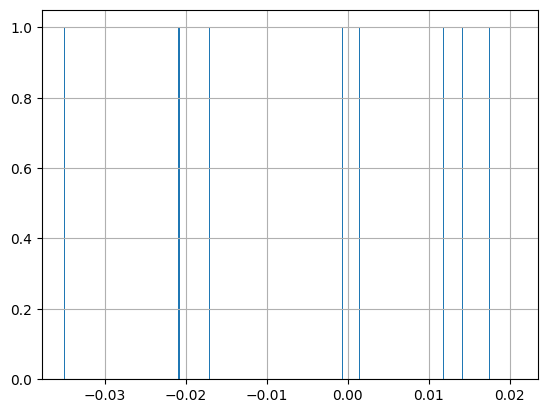

In [ ]:
element_effects['loc'].hist(bins=1000)
# plt.semilogy()
# plt.xlim([-5,5])

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will b

<Axes: xlabel='is_target', ylabel='z_value'>

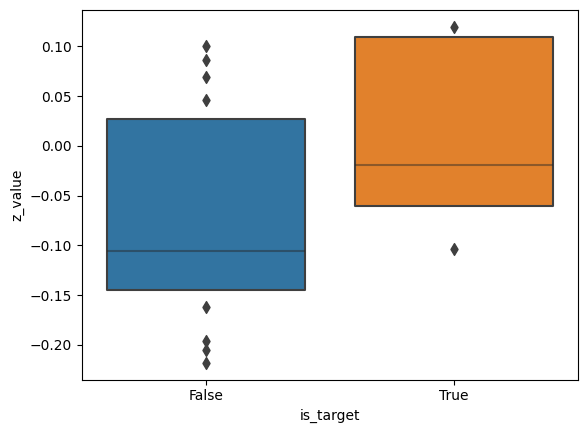

In [ ]:
sns.boxenplot(element_effects, x="is_target", y="z_value", scale="area")

In [ ]:
# scpower_df.sort_values('p_value')
sceptre_df=sceptre_df.assign(element=lambda x: x['guide'].str.split(r'|', regex=False, expand=True)[0])


In [ ]:
merge_df = element_effects.merge(sceptre_df, how="inner", on=["element", "gene"])

if not smoke_test:
    assert len(merge_df)==len(sceptre_df)

# len(merge_df)
# # merge_df.sort_values("SCEPTRE_p_value")

## Visualize hits



In [ ]:
from sklearn.linear_model import LinearRegression

reg_x=(merge_df[["z_value"]].values)
reg_y=(merge_df[["SCEPTRE_z_value"]].values)
reg = LinearRegression(fit_intercept=False).fit(reg_x, reg_y)
print("slope:", reg.coef_[0,0])
print("R^2:", reg.score(reg_x, reg_y))


slope: -0.5174959
R^2: -0.7406621324154985


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be r

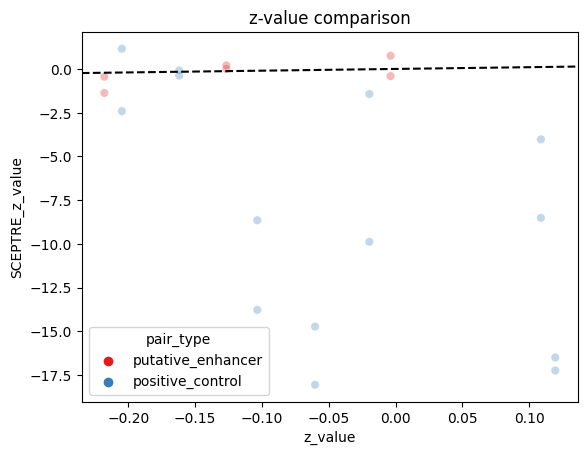

In [ ]:
plt.title("z-value comparison")
sns.scatterplot(merge_df, x='z_value', y='SCEPTRE_z_value', hue='pair_type', alpha=0.3, palette='Set1')
plt.axline((0, 0), slope=1, c='black', linestyle='dashed')
plt.show()


## Interactive data visualization
Need to subset and clip the data so that we can plot interactively

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be r

(1e-21, 2)

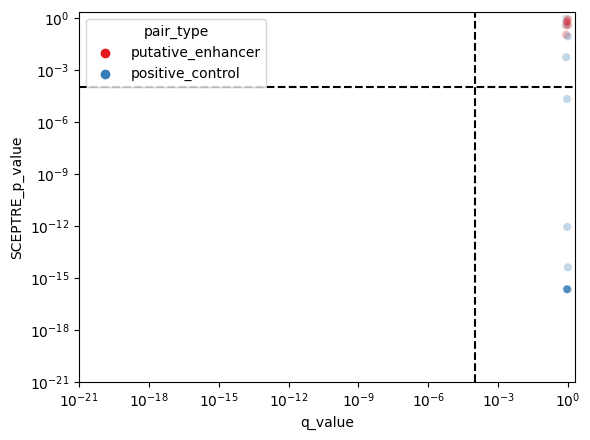

In [ ]:
# merge_df['p_value'] = np.maximum(merge_df['p_value'], min_p_value)

sns.scatterplot(merge_df, x="q_value", y="SCEPTRE_p_value", hue="pair_type", alpha=0.3, palette="Set1")
# plt.axline((0, 0), slope=1, c='black', linestyle='dashed')
plt.axhline(1e-4, c='black', linestyle='dashed')
plt.axvline(1e-4,  c='black', linestyle='dashed')

plt.loglog()
# plt.legend()
plt.xlim(1e-21, 2)
plt.ylim(1e-21, 2)

In [ ]:
min_p_value = 1e-100

subset_results = merge_df.query("q_value<0.01 or SCEPTRE_p_value < 0.01").copy()
# subset_results = merge_df.query("p_value<1e-5")
subset_results['p_value'] = np.maximum(subset_results['q_value'], min_p_value)
subset_results

,loc,scale,element,gene,z_value,q_value,is_target,guide,pair_type,SCEPTRE_p_value,SCEPTRE_z_value,log_fold_change,p_value
3,-0.032504,0.158666,UBE2T_TSS,ADIPOR1,-0.204856,0.837685,False,UBE2T_TSS|2,positive_control,5.235233e-03,-2.414258,-0.082662,0.837685
8,-0.017069,0.164965,ACTG1_TSS,ACTG1,-0.103473,0.917588,True,ACTG1_TSS|1,positive_control,2.220446e-16,-13.778191,-0.795850,0.917588
9,-0.017069,0.164965,ACTG1_TSS,ACTG1,-0.103473,0.917588,True,ACTG1_TSS|2,positive_control,8.657519e-13,-8.650491,-0.365572,0.917588
10,-0.009773,0.162196,ACTB_TSS,ACTB,-0.060253,0.951954,True,ACTB_TSS|1,positive_control,2.220446e-16,-18.059480,-0.430690,0.951954
11,-0.009773,0.162196,ACTB_TSS,ACTB,-0.060253,0.951954,True,ACTB_TSS|2,positive_control,2.220446e-16,-14.730568,-0.314530,0.951954
12,-0.003066,0.156578,ACYP1_TSS,ACYP1,-0.019582,0.984377,True,ACYP1_TSS|1,positive_control,4.052314e-15,-9.885435,-0.757634,0.984377
16,0.018060,0.165969,ALDH1A2_TSS,ALDH1A2,0.108817,0.913348,True,ALDH1A2_TSS|1,positive_control,2.034875e-05,-4.027007,-0.221476,0.913348
17,0.018060,0.165969,ALDH1A2_TSS,ALDH1A2,0.108817,0.913348,True,ALDH1A2_TSS|2,positive_control,2.220446e-16,-8.517287,-0.368654,0.913348
18,0.020667,0.172859,ADIPOR1_TSS,ADIPOR1,0.119559,0.904833,True,ADIPOR1_TSS|1,positive_control,2.220446e-16,-16.497062,-0.734725,0.904833
19,0.020667,0.172859,ADIPOR1_TSS,ADIPOR1,0.119559,0.904833,True,ADIPOR1_TSS|2,positive_control,2.220446e-16,-17.240641,-0.912983,0.904833


In [ ]:
pos_controls = merge_df.query("pair_type=='positive_control'")
pos_controls=pos_controls[~pos_controls['gene'].str.contains("-AS")] # remove alt start sites
pos_controls=pos_controls.assign(
    perturbo_rank=lambda x: x.groupby('guide')['q_value'].rank(),
    perturbo_p_rank=lambda x: x.groupby('guide')['z_value'].rank(),
    SCEPTRE_p_rank=lambda x: x.groupby('guide')['SCEPTRE_p_value'].rank(),
    SCEPTRE_z_rank=lambda x: x.groupby('guide')['SCEPTRE_z_value'].rank()
)
pos_controls

,loc,scale,element,gene,z_value,q_value,is_target,guide,pair_type,SCEPTRE_p_value,SCEPTRE_z_value,log_fold_change,perturbo_rank,perturbo_p_rank,SCEPTRE_p_rank,SCEPTRE_z_rank
2,-0.032504,0.158666,UBE2T_TSS,ADIPOR1,-0.204856,0.837685,False,UBE2T_TSS|1,positive_control,8.445764e-01,1.152195,0.038675,1.0,1.0,1.0,1.0
3,-0.032504,0.158666,UBE2T_TSS,ADIPOR1,-0.204856,0.837685,False,UBE2T_TSS|2,positive_control,5.235233e-03,-2.414258,-0.082662,1.0,1.0,1.0,1.0
4,-0.027240,0.168226,TMED10_TSS,ACYP1,-0.161926,0.871364,False,TMED10_TSS|1,positive_control,3.868178e-01,-0.380233,-0.025257,1.0,1.0,1.0,1.0
5,-0.027240,0.168226,TMED10_TSS,ACYP1,-0.161926,0.871364,False,TMED10_TSS|2,positive_control,5.178842e-01,-0.080194,-0.001552,1.0,1.0,1.0,1.0
8,-0.017069,0.164965,ACTG1_TSS,ACTG1,-0.103473,0.917588,True,ACTG1_TSS|1,positive_control,2.220446e-16,-13.778191,-0.795850,1.0,1.0,1.0,1.0
9,-0.017069,0.164965,ACTG1_TSS,ACTG1,-0.103473,0.917588,True,ACTG1_TSS|2,positive_control,8.657519e-13,-8.650491,-0.365572,1.0,1.0,1.0,1.0
10,-0.009773,0.162196,ACTB_TSS,ACTB,-0.060253,0.951954,True,ACTB_TSS|1,positive_control,2.220446e-16,-18.059480,-0.430690,1.0,1.0,1.0,1.0
11,-0.009773,0.162196,ACTB_TSS,ACTB,-0.060253,0.951954,True,ACTB_TSS|2,positive_control,2.220446e-16,-14.730568,-0.314530,1.0,1.0,1.0,1.0
12,-0.003066,0.156578,ACYP1_TSS,ACYP1,-0.019582,0.984377,True,ACYP1_TSS|1,positive_control,4.052314e-15,-9.885435,-0.757634,1.0,1.0,1.0,1.0
13,-0.003066,0.156578,ACYP1_TSS,ACYP1,-0.019582,0.984377,True,ACYP1_TSS|2,positive_control,8.212345e-02,-1.431670,-0.071350,1.0,1.0,1.0,1.0


In [ ]:
target_pairs = pos_controls.query('is_target')
print("our accuracy: "+str(len(target_pairs.query('perturbo_rank==1'))/len(target_pairs)))
print("SCEPTRE accuracy: "+str(len(target_pairs.query('SCEPTRE_z_rank==1'))/len(target_pairs)))
print("SCEPTRE accuracy: "+str(len(target_pairs.query('SCEPTRE_p_rank==1'))/len(target_pairs)))

our accuracy: 1.0
SCEPTRE accuracy: 1.0
SCEPTRE accuracy: 1.0


In [ ]:
# target_pairs.query('perturbo_rank==1 and SCEPTRE_z_rank>=2')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]
target_pairs.query('perturbo_rank==1 and SCEPTRE_p_rank>1')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]
# target_pairs.query('perturbo_rank>1 and SCEPTRE_p_rank==1')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]

,guide,gene,perturbo_rank,SCEPTRE_p_rank


In [ ]:
target_pairs.query('perturbo_rank>1 and SCEPTRE_p_rank==1')[['guide','gene','perturbo_rank','SCEPTRE_p_rank']]

,guide,gene,perturbo_rank,SCEPTRE_p_rank


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and

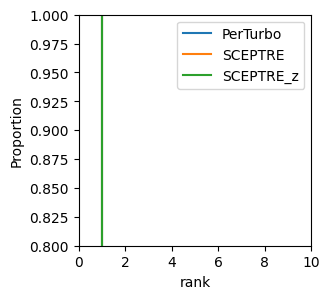

In [ ]:
with plt.rc_context({"figure.figsize": [3,3]}):

  sns.ecdfplot(pos_controls.query('is_target'), x='perturbo_rank',stat="proportion", label="PerTurbo")
  sns.ecdfplot(pos_controls.query('is_target'), x='SCEPTRE_p_rank',stat="proportion", label="SCEPTRE")
  sns.ecdfplot(pos_controls.query('is_target'), x='SCEPTRE_z_rank',stat="proportion", label="SCEPTRE_z")
  plt.legend()
  # plt.title("eCDF")
  # plt.semilogy()
  plt.xlabel("rank")
  plt.xlim([0,10])
  plt.ylim(0.8, 1)
  plt.show()

0.5628571428571428 0.990909090909091


Text(0.5, 1.0, 'perturbo vs. SCEPTRE p-values')

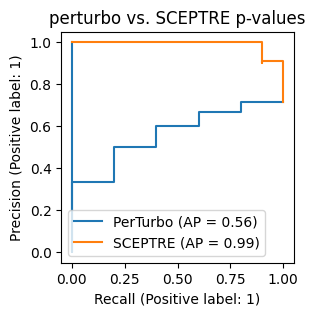

In [ ]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, average_precision_score, precision_recall_curve

with plt.rc_context({"figure.figsize": [3,3]}):
  roc = PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], 1-pos_controls['z_value'], name="PerTurbo")
  PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], 1-pos_controls['SCEPTRE_p_value'], ax=roc.ax_, name="SCEPTRE")

precision, recall, threshold = precision_recall_curve(pos_controls['is_target'], 1-pos_controls['z_value'])
score1=average_precision_score(pos_controls['is_target'], 1-pos_controls['z_value'])
score2=average_precision_score(pos_controls['is_target'], 1-pos_controls['SCEPTRE_p_value'])
print(score1, score2)
plt.title("perturbo vs. SCEPTRE p-values")
# svc_disp = RocCurveDisplay.from_estimator(X_test, y_test)
# rfc_disp = RocCurveDisplay.from_estimator(X_test, y_test, ax=svc_disp.ax_)


0.5628571428571428 0.9909090909090909


Text(0.5, 1.0, 'z-values')

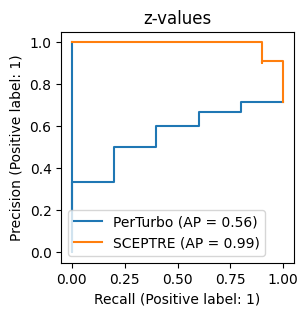

In [ ]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, average_precision_score, precision_recall_curve

with plt.rc_context({"figure.figsize": [3,3]}):
  roc = PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], -pos_controls['z_value'], name="PerTurbo")
  PrecisionRecallDisplay.from_predictions(pos_controls['is_target'], -pos_controls['SCEPTRE_z_value'], ax=roc.ax_, name="SCEPTRE")


precision, recall, threshold = precision_recall_curve(pos_controls['is_target'], 1-pos_controls['z_value'])
score1=average_precision_score(pos_controls['is_target'], -pos_controls['z_value'])
score2=average_precision_score(pos_controls['is_target'], -pos_controls['SCEPTRE_z_value'])
print(score1, score2)
plt.title('z-values')
# plt.title()
# svc_disp = RocCurveDisplay.from_estimator(X_test, y_test)
# rfc_disp = RocCurveDisplay.from_estimator(X_test, y_test, ax=svc_disp.ax_)


## experimental/future 

In [ ]:
# len(merge_df)
# len(sceptre_df)
# model.module.guide.median()['element_x_factor'].min()
loc, scale = model.module.guide._get_loc_and_scale("factor_x_gene")
factor_x_gene_z_score = (loc/scale).detach().numpy()

factor_x_gene_df = pd.DataFrame(
    factor_x_gene_z_score,
    columns = mdata['rna'].var_names
)
# sns.heatmap(factor_x_gene_df, cmap="vlag", center=0, vmin=-5, vmax=5)

sns.clustermap(factor_x_gene_df.T, cmap="vlag", center=0, vmin=-5, vmax=5, metric="cosine", figsize=(16,16))


AttributeError: 'AutoGuideList' object has no attribute '_get_loc_and_scale'

In [ ]:
# factor_x_gene_df.loc[5].sort_values()[-20:].index

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


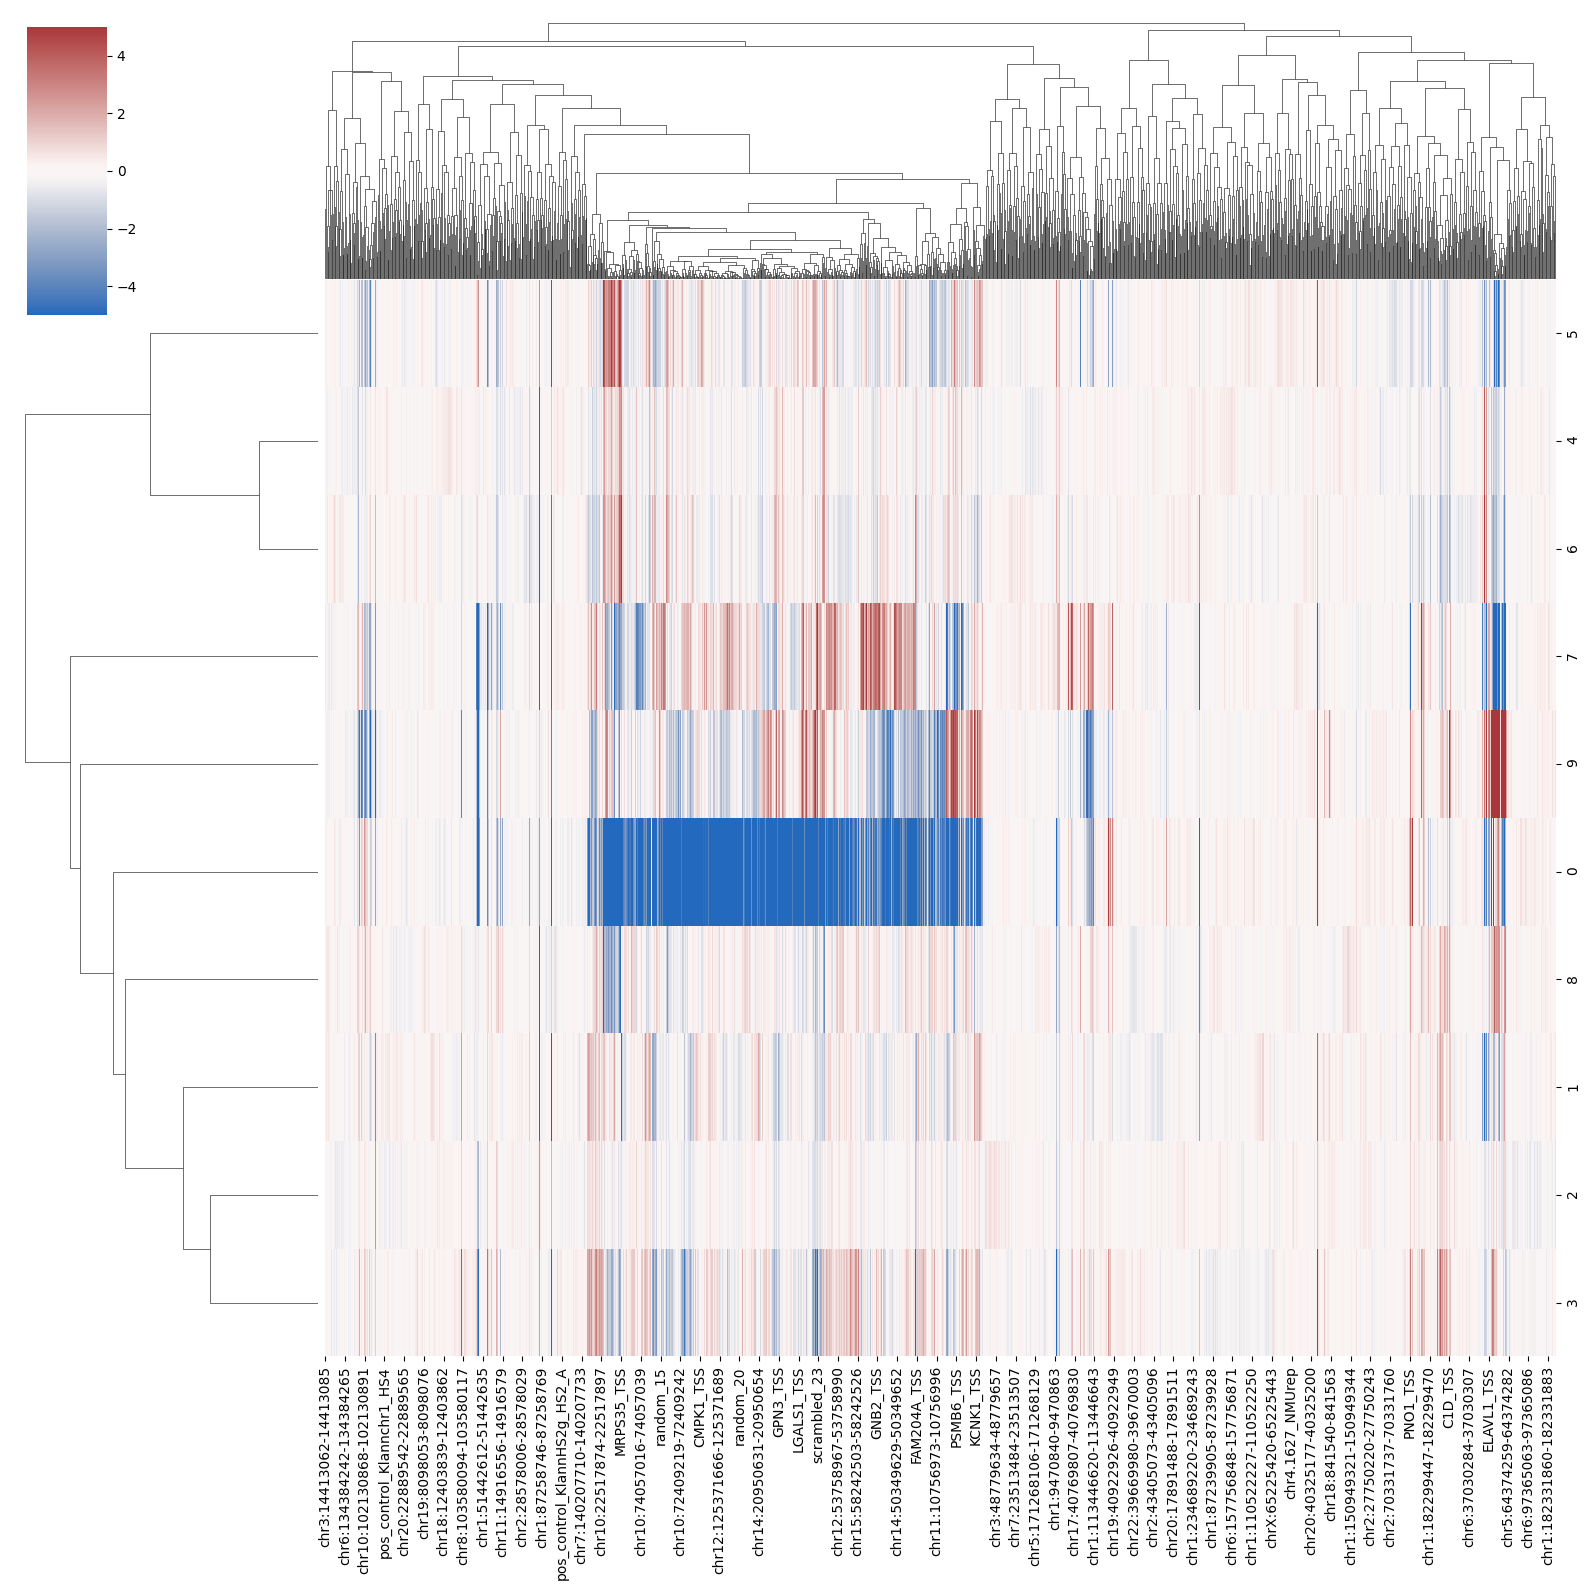

In [ ]:
loc, scale = model.module.guide._get_loc_and_scale("element_x_factor")
element_x_factor_z_score = (loc/scale).detach().numpy()

element_x_factor_df = pd.DataFrame(
    element_x_factor_z_score,
    index= mdata['grna'].varm['element_targeted'].columns
)
# sns.heatmap(element_x_factor_df, cmap="vlag", center=0)

sns.clustermap(element_x_factor_df.T, cmap="vlag", center=0, vmin=-5, vmax=5, metric="cosine",  figsize=(16,16))

# biggest_gene = model.module.guide.median()['factor_x_gene'][biggest_factor_idx, :].argmax()
# biggest_element = model.module.guide.median()['element_x_factor'][:, biggest_factor_idx].argmax()

# elements =  mdata['grna'].varm['element_targeted'].columns
# genes = mdata['rna'].var_names

# plt.bar(x=values[:10].numpy(), height=)

# mdata['grna'].varm['element_targeted'].columns[int(biggest_element)]
# mdata['rna'].var_names[int(biggest_gene)]

In [ ]:
# plt.plot(np.log(threshold), precision[:-1])

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# guide_1 = f"{plot_gene}_TSS|1"
# guide_2 = f"{plot_gene}_TSS|2"

gene_select = widgets.Dropdown(
    options=sorted(mdata['rna'].var_names),
    value=mdata['rna'].var_names[0],
    # rows=10,
    description='Gene',
    disabled=False
)


guide_select = widgets.Dropdown(
    options=sorted(mdata['grna'].var_names),
    value=mdata['grna'].var_names[0],
    # rows=10,
    description='Guide',
    disabled=False
)

display(gene_select, guide_select)

ModuleNotFoundError: No module named 'ipywidgets'

In [ ]:
# import scanpy as sc

# plot_guides = ['TMED10_TSS|1','TMED10_TSS|2']
# plot_genes = ['TMED10', 'KDELR2','KDELR3','SEC13', 'YIF1A', 'CALU', 'YIPF2', 'SDF2L1', 'MANF']

plot_genes = [gene_select.value]
plot_guides = [guide_select.value]


counts_df = mdata["rna"][:, plot_genes].to_df()
guide_obs = mdata["grna"][:, plot_guides].X.sum(axis=1).copy().astype(bool)
counts_df['guide_obs']=guide_obs


# mdata['rna'].obs['TMED10_TSS'] = guide_obs
# mdata['rna'].obs['TMED10_TSS']=mdata['rna'].obs['TMED10_TSS'].astype("category")
# # mdata['rna'].raw = mdata['rna']
# # sc.pp.normalize_total(mdata['rna'])
# with plt.rc_context({'figure.dpi':200}):
#   sc.pl.dotplot(mdata['rna'], plot_genes, groupby='TMED10_TSS', title='TMED10_TSS')

NameError: name 'gene_select' is not defined

In [ ]:
# plot_gene = gene_select.value
# plot_guide = guide_select.value
# print(plot_gene, plot_guide)

# plot_df = pd.DataFrame({"count": counts, "has_guide": guide_obs})
plot_df = counts_df.melt(id_vars='guide_obs',var_name='gene',value_name='count')
g = sns.FacetGrid(plot_df, col="gene", row="guide_obs",sharey=False)
g.map_dataframe(
    sns.histplot,
    x="count", binwidth=1,
    hue_order=[False,True],
    # log_scale=[False,True]
)
plt.xlim(0,50)
# plt.semilogy()

# sns.histplot(
#     plot_df.query('has_guide'),
#     x="count",
#     hue="has_guide",
#     binwidth=1,
#     common_norm=False,
#     stat="density",
# )
# plt.show()
# sns.histplot(
#     plot_df.query('not has_guide'),
#     x="count",
#     hue="has_guide",
#     binwidth=1,
#     common_norm=False,
#     stat="density",
# )
# # plt.xlim(0, 50)
# g.title(f"gene: {plot_gene}, guide: {plot_guide}")
# plt.show()



NameError: name 'counts_df' is not defined

In [ ]:
!pwd

/Users/ljb80/Projects/perturbo/reproducibility


In [ ]:
import altair as alt

alt.Chart(subset_results).mark_point().encode(
  x='z_value',
  y='SCEPTRE_z_value',
  color='is_target',
  tooltip=['guide','gene', 'z_value', 'SCEPTRE_z_value'] 
).interactive()


ModuleNotFoundError: No module named 'altair'

#### scpower_df.to_csv(f"{data_dir}/scpower_results.csv")